In [64]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


plt.style.use('seaborn-v0_8')  


In [18]:
df = pd.read_csv("/Users/udaykiranvemala/Downloads/netflix_titles.csv")


In [76]:
df.head()
    


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,year_added,month_added,decade,main_genre
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,Unknown,United States,2021-09-25,2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm...",2021.0,9.0,2010-20,Documentaries
1,s2,TV Show,Blood & Water,Unknown,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...",2021.0,9.0,NaN,International TV Shows
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",Unknown,2021-09-24,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...,2021.0,9.0,NaN,Crime TV Shows
3,s4,TV Show,Jailbirds New Orleans,Unknown,Unknown,Unknown,2021-09-24,2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo...",2021.0,9.0,NaN,Docuseries
4,s5,TV Show,Kota Factory,Unknown,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...,2021.0,9.0,NaN,International TV Shows


In [21]:
df.info()
df.describe(include='all')
df.isnull().sum()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64

In [70]:
df['director'] = df['director'].fillna("Unknown")
df['cast'] = df['cast'].fillna("Unknown")
df['country'] = df['country'].fillna("Unknown")
df['rating'] = df['rating'].fillna(df['rating'].mode()[0])


In [71]:
df['date_added'] = pd.to_datetime(df['date_added'])
df['year_added'] = df['date_added'].dt.year
df['month_added'] = df['date_added'].dt.month


In [72]:
df['release_year'] = df['release_year'].astype(int)


In [73]:
bins = [1920, 1940, 1960, 1980, 2000, 2010, 2020]
labels = ["1920s-40s", "40s-60s", "60s-80s", "80s-2000", "2000-10", "2010-20"]

df['decade'] = pd.cut(df['release_year'], bins=bins, labels=labels)


In [74]:
df['main_genre'] = df['listed_in'].apply(lambda x: x.split(",")[0])


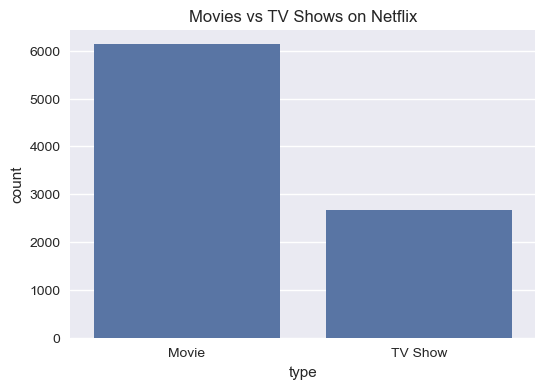

In [75]:
plt.figure(figsize=(6,4))
sns.countplot(data=df, x='type')
plt.title("Movies vs TV Shows on Netflix")
plt.show()


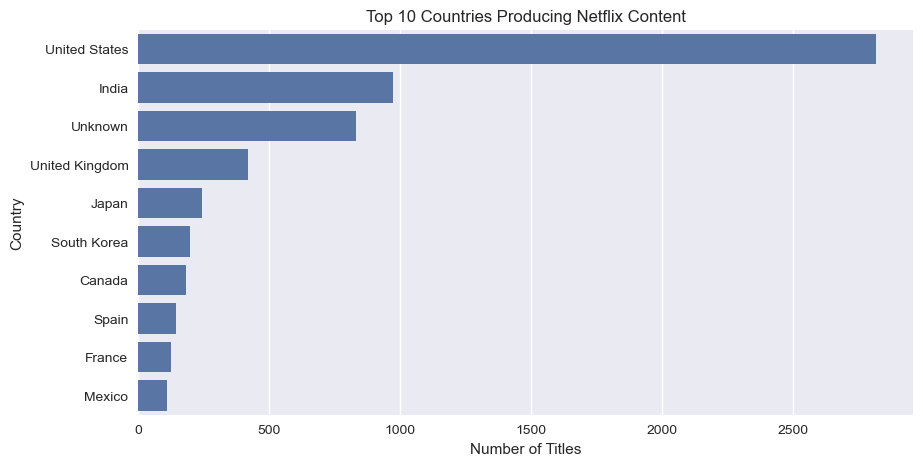

In [68]:
country_count = df['country'].value_counts().head(10)

plt.figure(figsize=(10,5))
sns.barplot(x=country_count.values, y=country_count.index)
plt.title("Top 10 Countries Producing Netflix Content")
plt.xlabel("Number of Titles")
plt.ylabel("Country")
plt.show()


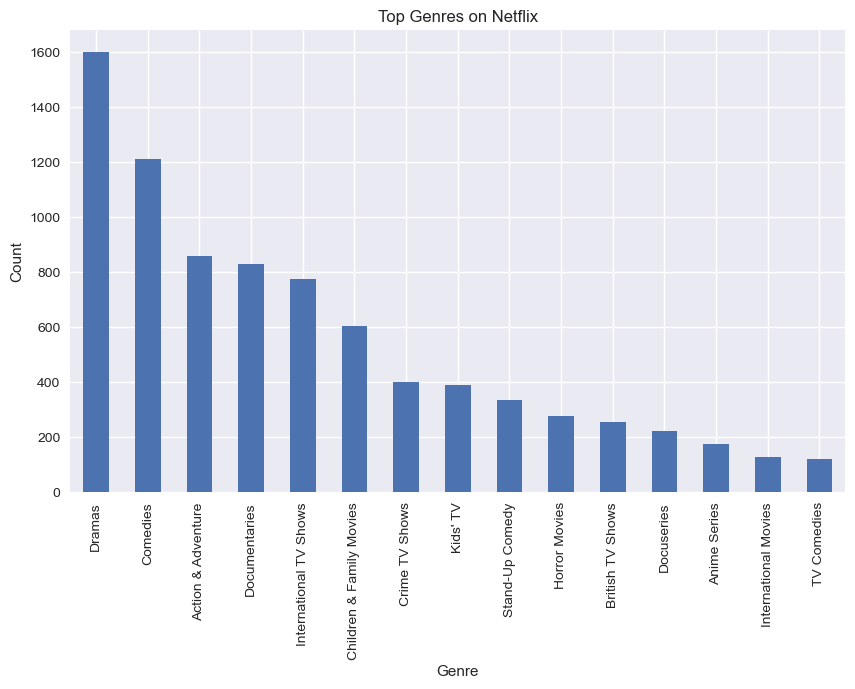

In [67]:
plt.figure(figsize=(10,6))
df['main_genre'].value_counts().head(15).plot(kind='bar')
plt.title("Top Genres on Netflix")
plt.xlabel("Genre")
plt.ylabel("Count")
plt.show()


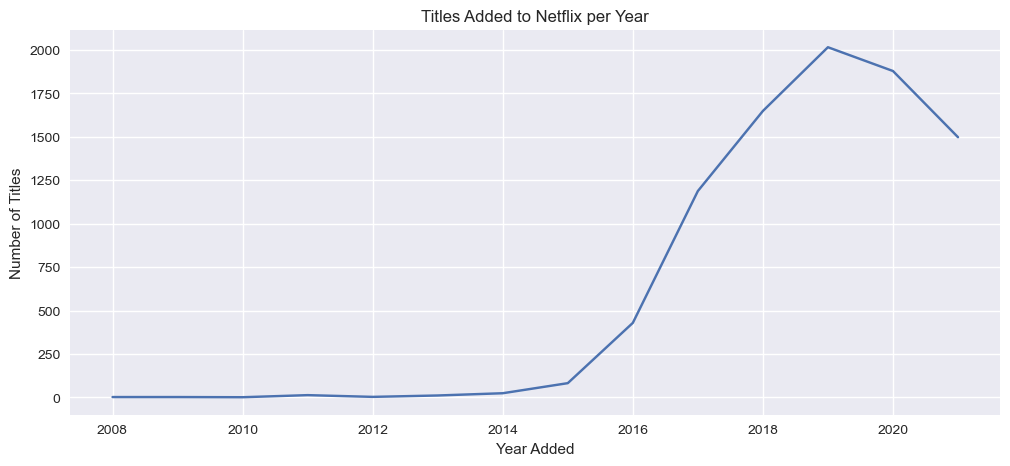

In [66]:
plt.figure(figsize=(12,5))
df['year_added'].value_counts().sort_index().plot()
plt.title("Titles Added to Netflix per Year")
plt.xlabel("Year Added")
plt.ylabel("Number of Titles")
plt.show()


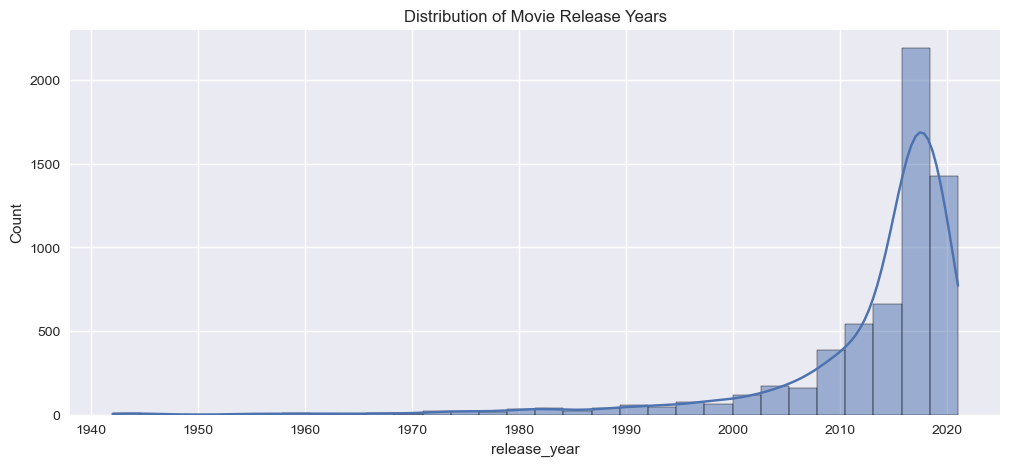

In [65]:
plt.figure(figsize=(12,5))
sns.histplot(df[df['type']=='Movie']['release_year'], bins=30, kde=True)
plt.title("Distribution of Movie Release Years")
plt.show()
